<a href="https://colab.research.google.com/github/hkumi/Be12pp-simulation/blob/main/Project_11_Medical_Insurance_Cost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing dependencies

In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

#Reading data

In [2]:
insurance_dataset = pd.read_csv("/content/insurance.csv")

#Data Analysis

In [3]:
insurance_dataset.shape

(1338, 7)

In [4]:
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
insurance_dataset.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [7]:
insurance_dataset['age'].value_counts()

,count
age,
18,69
19,68
50,29
51,29
47,29
46,29
45,29
20,29
48,29


In [8]:
insurance_dataset['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


In [9]:
insurance_dataset['children'].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


In [10]:
insurance_dataset['sex'].value_counts()

,count
sex,
male,676
female,662


In [11]:
insurance_dataset['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


#Correlation

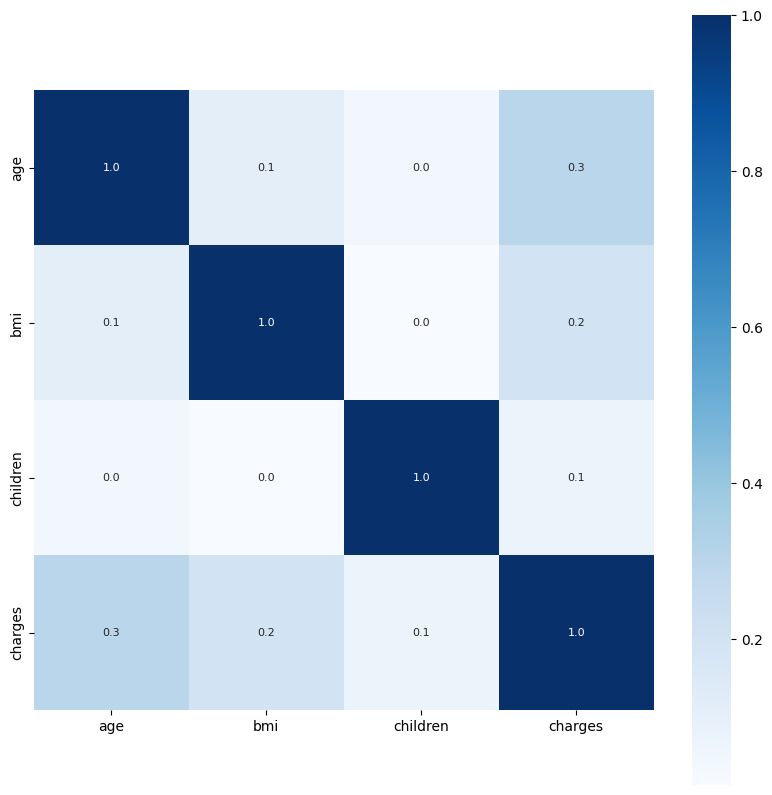

In [14]:
correlation = insurance_dataset.corr(numeric_only=True)
# Plot the heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(correlation, cbar=True, square=True, fmt=".1f", annot=True, annot_kws={"size": 8}, cmap="Blues")
plt.show()

#Replacing the text with numericals

In [15]:

insurance_dataset.replace({"smoker":{"no":0,"yes":1}},inplace=True)

In [16]:

insurance_dataset.replace({"sex":{"male":0,"female":1}},inplace=True)

In [17]:

insurance_dataset.replace({"region":{"southeast":0,"southwest":1,"northwest":2,"northeast":3}},inplace=True)

In [18]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,1,16884.92400
1,18,0,33.770,1,0,0,1725.55230
2,28,0,33.000,3,0,0,4449.46200
3,33,0,22.705,0,0,2,21984.47061
4,32,0,28.880,0,0,2,3866.85520


#Data Visualization

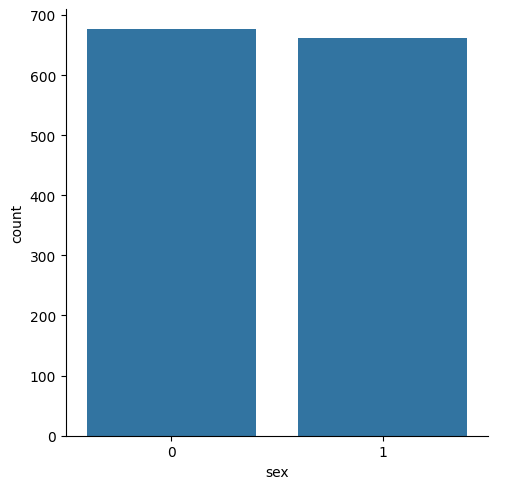

In [20]:
sns.catplot(x="sex",data=insurance_dataset,kind="count")

<Axes: xlabel='charges', ylabel='Count'>

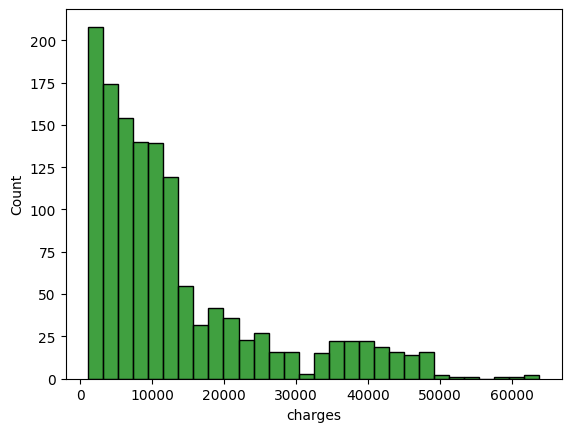

In [45]:
sns.histplot(insurance_dataset['charges'],color="green")

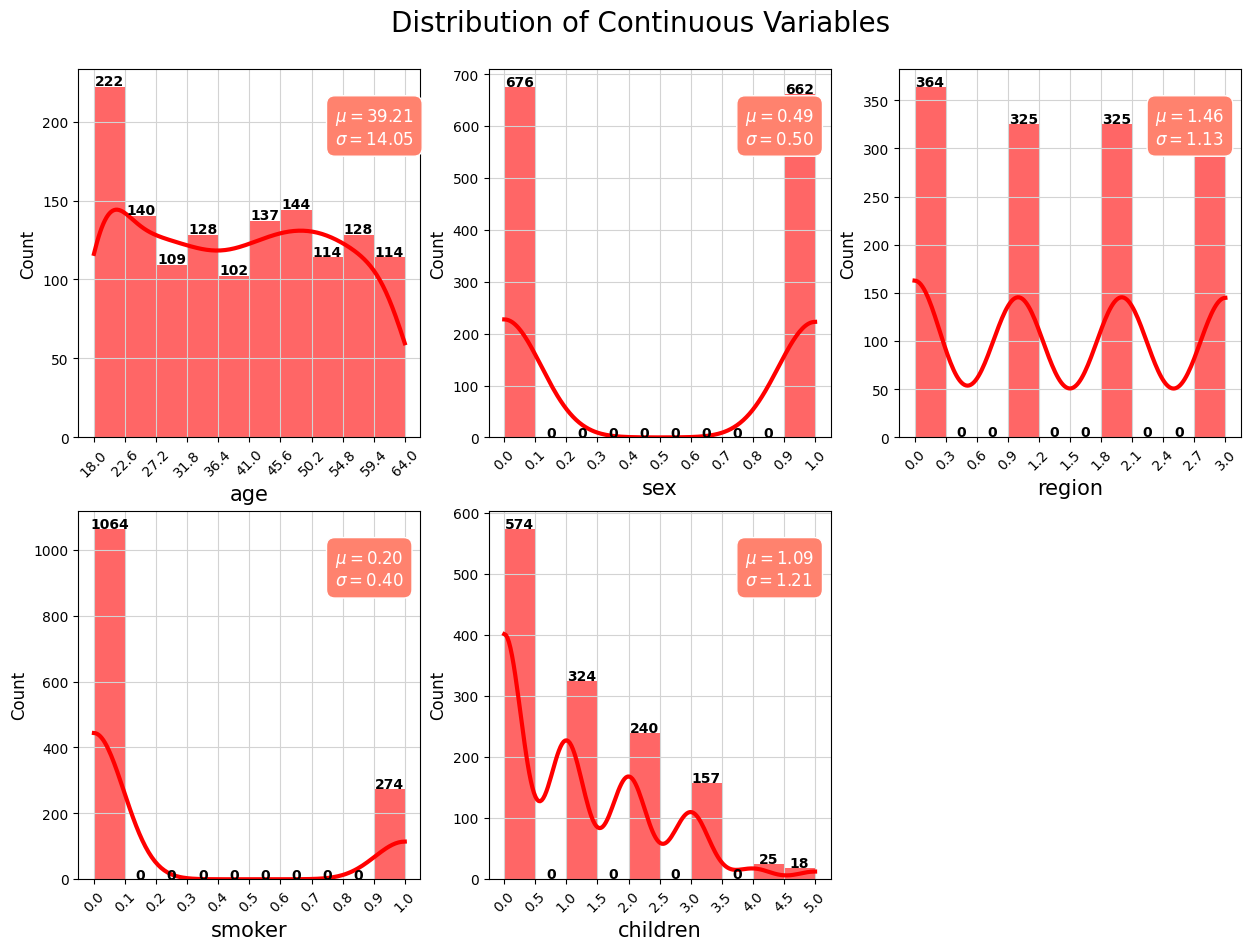

In [22]:
# Filter out continuous features for the univariate analysis
# Define the continuous features
continuous_features = ['age', 'sex', 'region', 'smoker', 'children']
df_continuous = insurance_dataset[continuous_features]

# Set up the subplot
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

# Loop to plot histograms for each continuous feature
for i, col in enumerate(df_continuous.columns):
    x = i // 3
    y = i % 3
    values, bin_edges = np.histogram(df_continuous[col],
                                     range=(np.floor(df_continuous[col].min()), np.ceil(df_continuous[col].max())))

    graph = sns.histplot(data=df_continuous, x=col, bins=bin_edges, kde=True, ax=ax[x, y],
                         edgecolor='none', color='red', alpha=0.6, line_kws={'lw': 3})
    ax[x, y].set_xlabel(col, fontsize=15)
    ax[x, y].set_ylabel('Count', fontsize=12)
    ax[x, y].set_xticks(np.round(bin_edges, 1))
    ax[x, y].set_xticklabels(ax[x, y].get_xticks(), rotation=45)
    ax[x, y].grid(color='lightgrey')

    for j, p in enumerate(graph.patches):
        ax[x, y].annotate('{}'.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                          ha='center', fontsize=10, fontweight="bold")

    textstr = '\n'.join((
        r'$\mu=%.2f$' % df_continuous[col].mean(),
        r'$\sigma=%.2f$' % df_continuous[col].std()
    ))
    ax[x, y].text(0.75, 0.9, textstr, transform=ax[x, y].transAxes, fontsize=12, verticalalignment='top',
                  color='white', bbox=dict(boxstyle='round', facecolor='#ff826e', edgecolor='white', pad=0.5))

ax[1,2].axis('off')
plt.suptitle('Distribution of Continuous Variables', fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

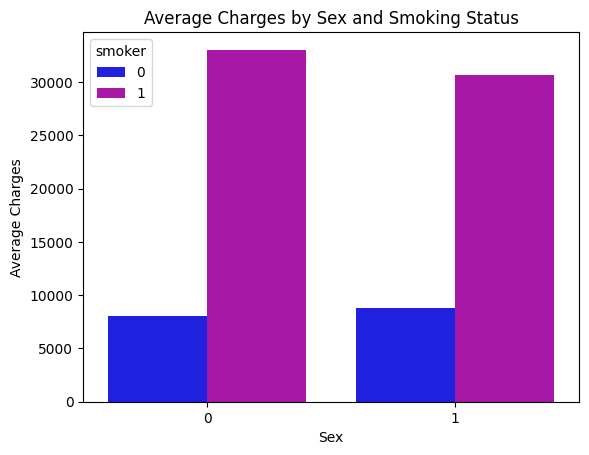

In [47]:
grouped_data = insurance_dataset.groupby(['sex', 'smoker'])[['charges']].mean().reset_index()

sns.barplot(x='sex', y='charges', hue='smoker', data=grouped_data, palette=['b', 'm'])

plt.title('Average Charges by Sex and Smoking Status')
plt.ylabel('Average Charges')
plt.xlabel('Sex')

plt.show()

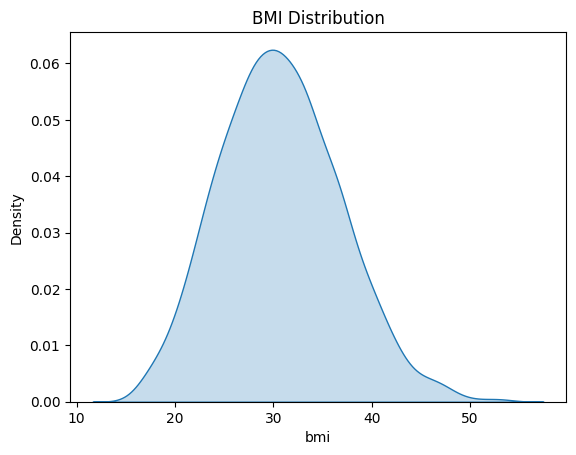

In [48]:
sns.kdeplot(insurance_dataset['bmi'], fill='True')
plt.title('BMI Distribution')
plt.show()

<ipython-input-49-1cd47c3a2f36>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y= 'age', palette=["b", "m"], data=insurance_dataset)


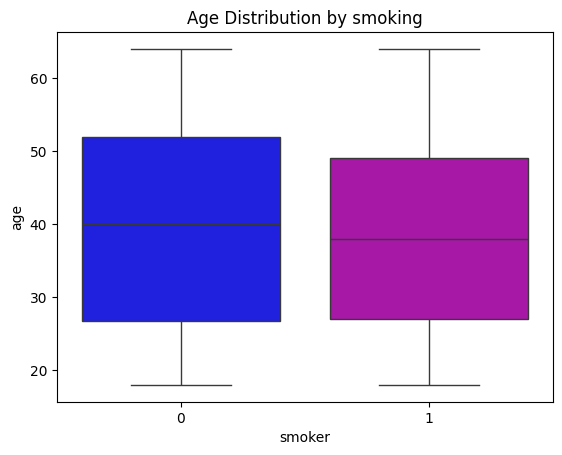

In [49]:
sns.boxplot(x='smoker', y= 'age', palette=["b", "m"], data=insurance_dataset)
plt.title('Age Distribution by smoking')
plt.show()

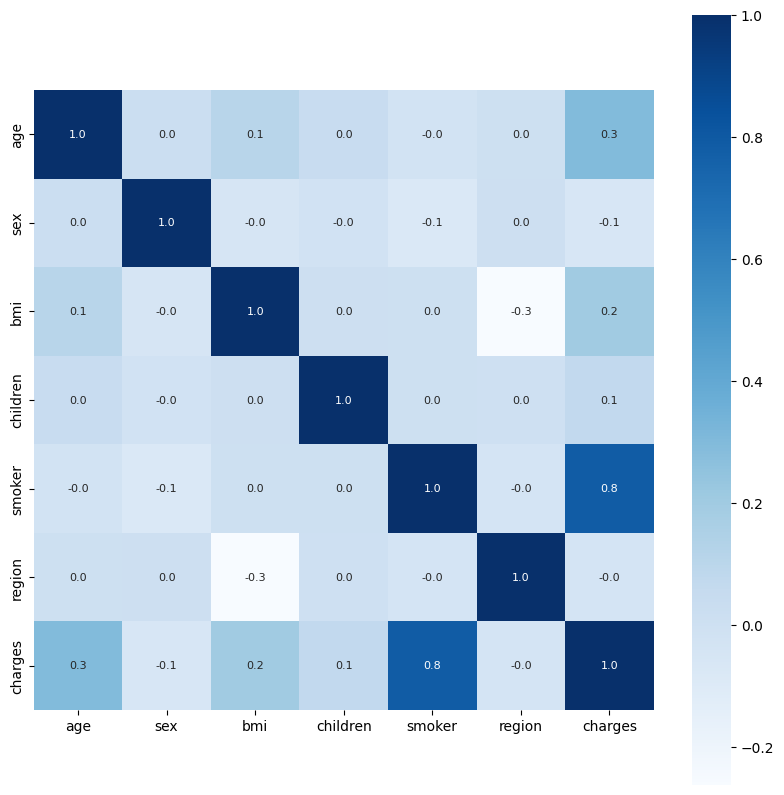

In [24]:
correlation = insurance_dataset.corr(numeric_only=True)
# Plot the heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(correlation, cbar=True, square=True, fmt=".1f", annot=True, annot_kws={"size": 8}, cmap="Blues")
plt.show()

#Splitting the data and model training

In [25]:
X = insurance_dataset.drop(columns="charges", axis = 1)
Y = insurance_dataset["charges"]

In [26]:
print(X)

      age  sex     bmi  children  smoker  region
0      19    1  27.900         0       1       1
1      18    0  33.770         1       0       0
2      28    0  33.000         3       0       0
3      33    0  22.705         0       0       2
4      32    0  28.880         0       0       2
...   ...  ...     ...       ...     ...     ...
1333   50    0  30.970         3       0       2
1334   18    1  31.920         0       0       3
1335   18    1  36.850         0       0       0
1336   21    1  25.800         0       0       1
1337   61    1  29.070         0       1       2

[1338 rows x 6 columns]


In [27]:
print(Y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


In [29]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [30]:
print(X_train.shape)

(1070, 6)


In [33]:
model = RandomForestRegressor()

In [34]:
model.fit(X_train,Y_train)

RandomForestRegressor()

In [37]:
#prediction on the training data
X_train_prediction = model.predict(X_train)
#R squared error.
score_1 = metrics.r2_score(Y_train,X_train_prediction)
#Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_train,X_train_prediction)
#this values should be closer to 1 and 0 respectively
print(score_1)
print(score_2)

0.9772300607658958
983.1639782573645


In [38]:
#Accuracy on test data
X_test_prediction = model.predict(X_test)

In [39]:
#R squared error.
test_score_1 = metrics.r2_score(Y_test,X_test_prediction)
#Mean Absolute Error
test_score_2 = metrics.mean_absolute_error(Y_test,X_test_prediction)
#this values should be closer to 1 and 0 respectively
print(test_score_1)
print(test_score_2)

0.8344320653577079
2717.0231744818657


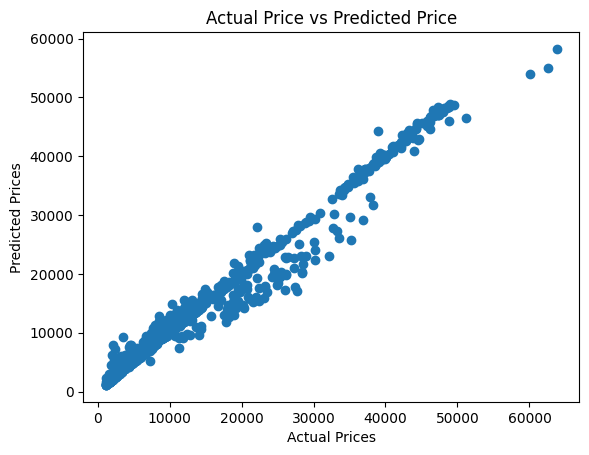

In [40]:
plt.scatter(Y_train,X_train_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Price vs Predicted Price")
plt.show()

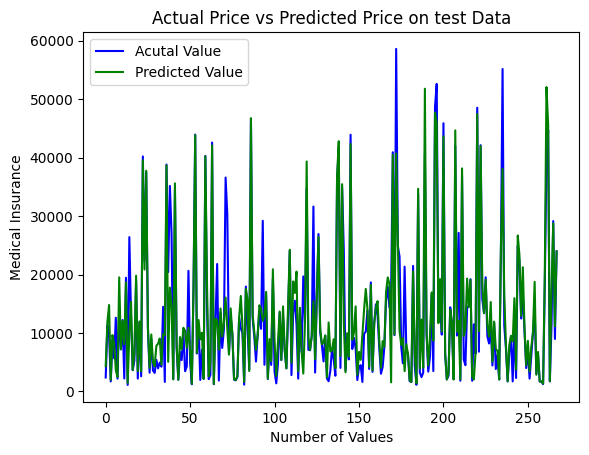

In [44]:
Y_test=list(Y_test)
plt.plot(Y_test,color="blue",label = "Acutal Value")
plt.plot(X_test_prediction,color="green",label = "Predicted Value")
plt.title("Actual Price vs Predicted Price on test Data")
plt.xlabel("Number of Values")
plt.ylabel("Medical Insurance")
plt.legend()
plt.show()

#Mkaing Predictive system

In [42]:
input_data = (19,	1,	27.900,	0,	1,	1)

#changing the data type into numpy array

input_data_as_numpy_array = np.asarray(input_data)
#reshape the numpy array as we are predicting for one instance
input_data_reshape = input_data_as_numpy_array.reshape(1,-1)
prediction = model.predict(input_data_reshape)
print("your insurance cost will can be  :",  prediction ,"dollars")



your insurance cost will can be  : [16901.18437] dollars


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
